Loaded synthetic data
Shape   : (1000, 7)
Columns : ['battery_voltage', 'solar_current', 'panel_temp', 'onboard_temp', 'attitude_error', 'reaction_wheel_rpm', 'label']
Faults  : 124
Nominal : 876
No low-variance columns found — keeping all features
X_train : (800, 6)  faults: 99
X_val   : (200, 6)  faults: 25
Epoch  10/50 — misclassifications: 0
Epoch  20/50 — misclassifications: 0
Epoch  30/50 — misclassifications: 0
Epoch  40/50 — misclassifications: 0
Epoch  50/50 — misclassifications: 0

--- numpy_slp Results ---
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
Saved loss curve to ../outputs/plots/loss_curve_numpy_slp.png


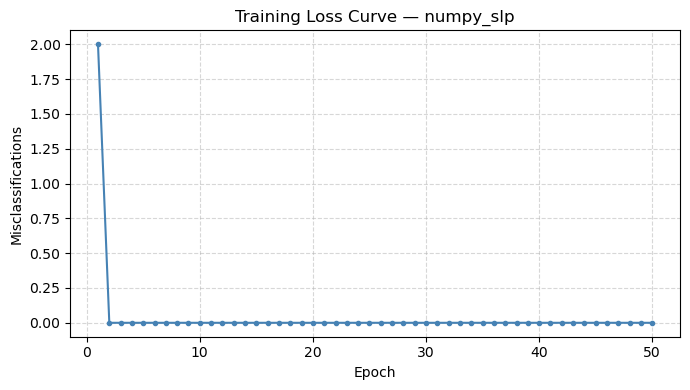

Saved confusion matrix to ../outputs/plots/confusion_matrix_numpy_slp.png


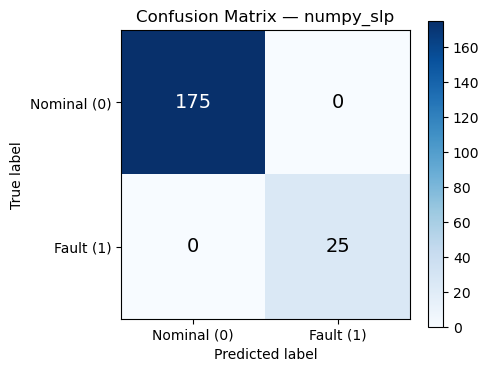

Results saved to ../outputs/results.csv


In [1]:
import sys
sys.path.append("../src")

from data_loader import load
from preprocessor import preprocess
from perceptron_numpy import train, predict
from evaluate import compute_metrics, plot_confusion_matrix, plot_loss_curve, save_results

# load and preprocess
df = load(source="synthetic")
X_train, X_val, y_train, y_val = preprocess(df)

# train
w, b, losses = train(X_train, y_train, lr=0.01, epochs=50)

# predict
y_pred = predict(X_val, w, b)

# evaluate
metrics = compute_metrics(y_val, y_pred, model_name="numpy_slp")

# plots
plot_loss_curve(losses, model_name="numpy_slp")
plot_confusion_matrix(y_val, y_pred, model_name="numpy_slp")

# save results
save_results(metrics)